## Step 1 - Init python stuff

In [1]:
import s3fs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" #utilise cpu et non gpu

import tensorflow as tf
print(tf.config.list_physical_devices())
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import TensorBoard

import sys
sys.path.append("/home/onyxia/gen-ai-fwi")
from models.DCGAN    import DCGAN
from callbacks.ImagesCallback import ImagesCallback

import fidle

I0000 00:00:1777211416.264258   21055 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777211416.329537   21055 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777211417.602619   21055 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1777211418.431074   21055 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Step 2 - Parameters

In [2]:
latent_dim    = 64

scale         = .01
epochs        = 5
batch_size    = 32
num_img       = 12
fit_verbosity = 1


## Step 3 - Load data

In [3]:
# =========================================================
# 1. RECHARGEMENT DU PARQUET DEPUIS MINIO
# =========================================================
MY_BUCKET = "matheo"
CHEMIN_FICHIER_OUT = "diffusion/data/fwi_se_spain_28x28.parquet"
VALUE_COL = "fwi-daily-proj"
GRID_SIZE = 28

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})
with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER_OUT}", "rb") as f:
    df_loaded = pd.read_parquet(f)

print(f"DataFrame rechargé : {df_loaded.shape}")
print(df_loaded.head())

# =========================================================
# 2. RECONSTRUCTION DU TENSEUR (N, 28, 28)
# =========================================================
# On trie par (time, lat, lon) pour retrouver exactement l'ordre du ravel
# utilisé lors de la sauvegarde. `meshgrid(se_lon_centers, se_lat_centers)`
# produit LAT variant par ligne, LON variant par colonne ; le ravel parcourt
# donc les lignes (lat fixe, lon croissante) puis les latitudes dans l'ordre
# où elles apparaissent dans se_lat_centers (croissante).
df_sorted = df_loaded.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

# Vérification : chaque date doit avoir exactement 784 pixels
counts = df_sorted.groupby("time").size()
assert (counts == GRID_SIZE * GRID_SIZE).all(), \
    f"Certaines dates n'ont pas {GRID_SIZE*GRID_SIZE} pixels"

# Conversion en tenseur (N, 28, 28)
n_dates = df_sorted["time"].nunique()
X = df_sorted[VALUE_COL].values.reshape(n_dates, GRID_SIZE, GRID_SIZE,1)
dates = np.sort(df_sorted["time"].unique())

print(f"Tenseur X : {X.shape}")   # (N, 28, 28)
print(f"min = {X.min():.3f}, max = {X.max():.3f}, mean = {X.mean():.3f}")

# =========================================================
# 2b. NORMALISATION (log1p + min-max)
# =========================================================
X = np.log1p(X)
X_min, X_max = X.min(), X.max()
X = (X - X_min) / (X_max - X_min + 1e-8)
print(f"X normalisé : min={X.min():.3f}, max={X.max():.3f}")


DataFrame rechargé : (10308816, 4)
        time        lat       lon  fwi-daily-proj
0 1970-01-01  37.267857 -8.548214             1.0
1 1970-01-01  37.267857 -8.244643             1.0
2 1970-01-01  37.267857 -7.941071             1.0
3 1970-01-01  37.267857 -7.637500             1.0
4 1970-01-01  37.267857 -7.333929             1.0
Tenseur X : (13149, 28, 28, 1)
min = 0.000, max = 211.122, mean = 15.011
X normalisé : min=0.000, max=1.000


## Step 4 - Visualize data

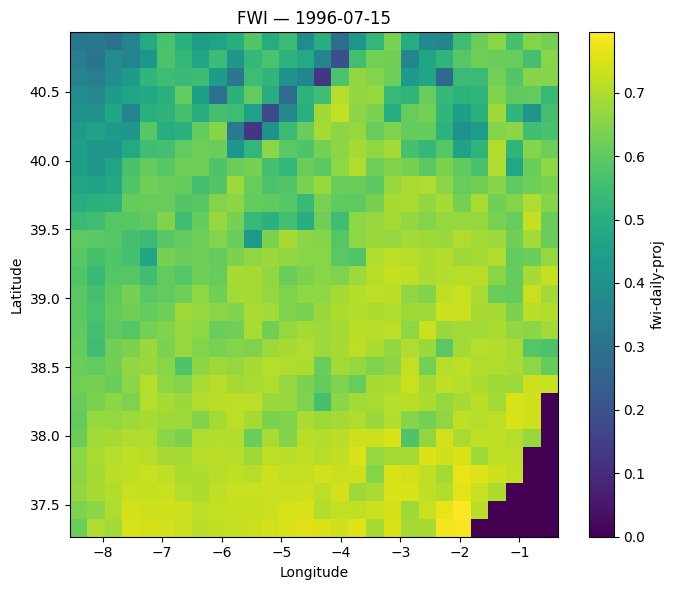

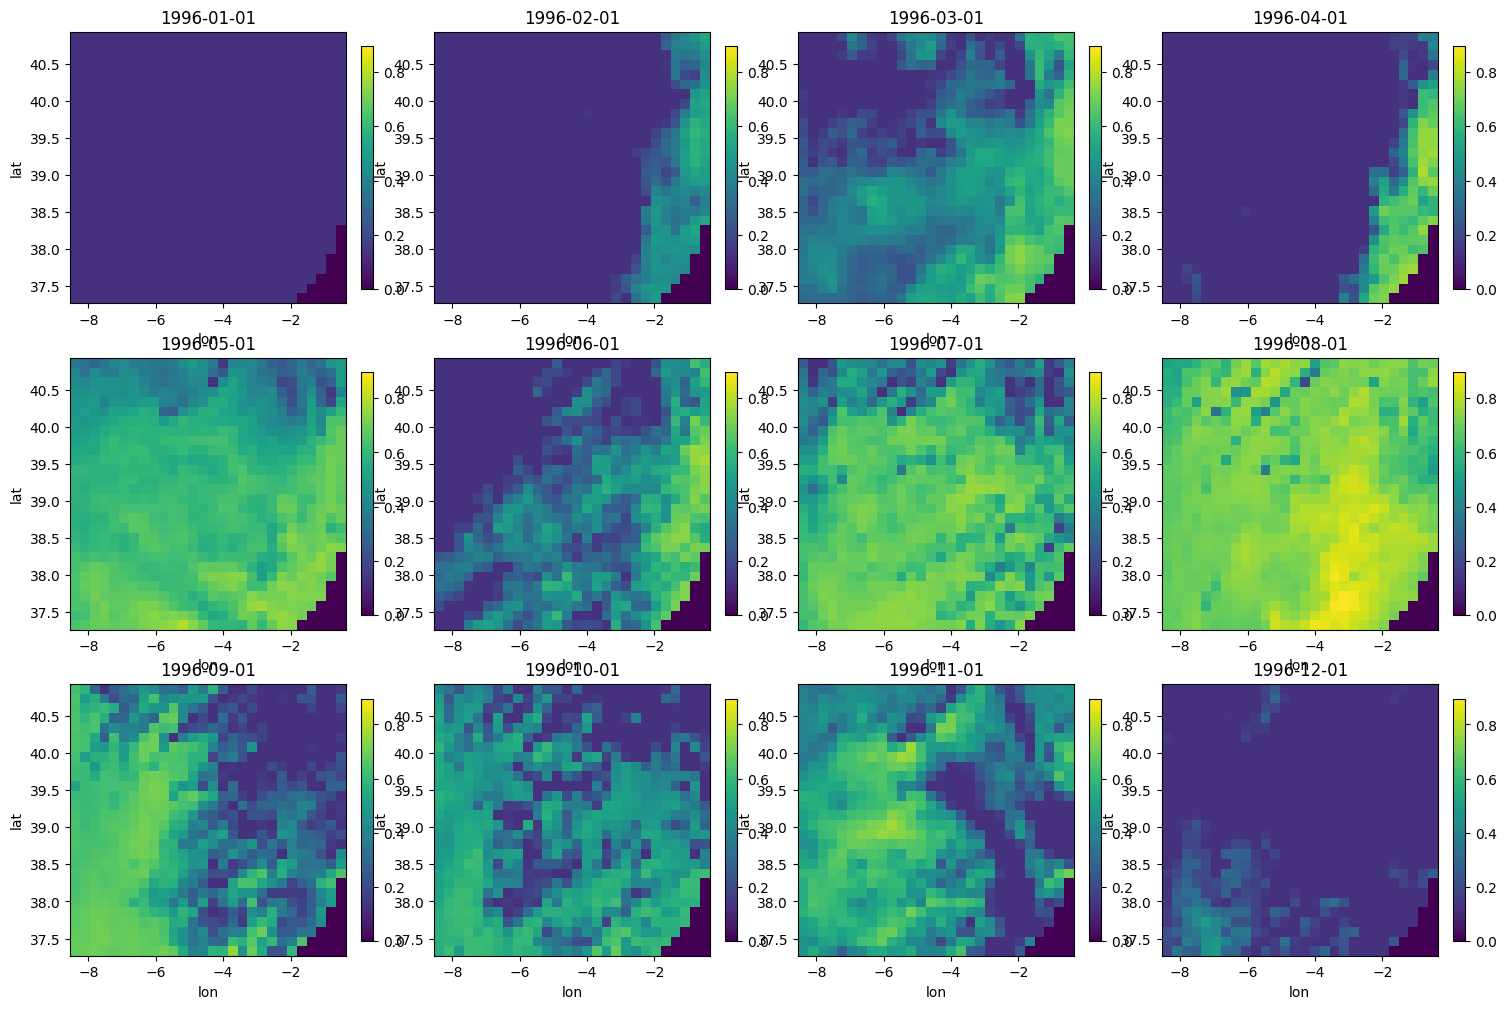

In [4]:
run_dir = '/home/onyxia/gen-ai-fwi' #a changer selon votre configuration

import matplotlib.pyplot as plt

# =========================================================
# 3. RÉAFFICHAGE D'UNE CARTE AVEC COORDONNÉES LON/LAT
# =========================================================
# On récupère les centres de pixels depuis le dataframe rechargé
lon_centers = np.sort(df_loaded["lon"].unique())   # 28 valeurs
lat_centers = np.sort(df_loaded["lat"].unique())   # 28 valeurs
assert len(lon_centers) == GRID_SIZE and len(lat_centers) == GRID_SIZE

# Emprise géographique (pour axer le plot)
extent = [lon_centers.min(), lon_centers.max(),
          lat_centers.min(), lat_centers.max()]

# ---------- Option 1 : une seule date ----------
def plot_one_date(date, X, dates, extent, title_prefix="FWI"):
    i = np.where(dates == np.datetime64(date))[0]
    if len(i) == 0:
        print(f"Date {date} non trouvée dans le dataset.")
        return
    i = i[0]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(X[i], origin="lower", extent=extent,
                   cmap="viridis", aspect="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title_prefix} — {str(dates[i])[:10]}")
    plt.colorbar(im, ax=ax, label=VALUE_COL)
    plt.tight_layout()
    plt.show()

plot_one_date("1996-07-15", X, dates, extent)


# ---------- Option 2 : grille 3x4 pour les 12 mois de 1996 ----------
dates_plot = ['1996-01-01','1996-02-01','1996-03-01',
              '1996-04-01','1996-05-01','1996-06-01',
              '1996-07-01','1996-08-01','1996-09-01',
              '1996-10-01','1996-11-01','1996-12-01']
dates_plot = [np.datetime64(d) for d in dates_plot]

# Échelle de couleur commune sur les 12 mois
indices = [np.where(dates == d)[0][0] for d in dates_plot if d in dates]
stack = X[indices]
vmin, vmax = stack.min(), stack.max()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for ax, idx in zip(axes, indices):
    im = ax.imshow(X[idx], origin="lower", extent=extent,
                   cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(str(dates[idx])[:10])
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    plt.colorbar(im, ax=ax, fraction=0.04)
# ✅ Save figure
plt.savefig(f"{run_dir}/FWI_28x28_parquet", dpi=300, bbox_inches="tight")
plt.show()

## Step 5 - Create a discriminator

In [5]:
inputs  = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, kernel_size=4, strides=2, padding='same')(inputs)
x = layers.LeakyReLU(negative_slope=0.2)(x)
x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same')(x)
x = layers.LeakyReLU(negative_slope=0.2)(x)
x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same')(x)
x = layers.LeakyReLU(negative_slope=0.2)(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
discriminator = keras.Model(inputs, outputs, name='discriminator')
discriminator.summary()


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,001 (390.63 KB)

 Trainable params: 100,001 (390.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 32)(inputs)
x = layers.Reshape((7, 7, 32))(x)
x = layers.UpSampling2D()(x)
x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = layers.UpSampling2D()(x)
x = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(x)
outputs = layers.Conv2D(1, kernel_size=3, padding='same', activation='sigmoid')(x)
generator = keras.Model(inputs, outputs, name='generator')
generator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1568)           │       101,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,169 (543.63 KB)

 Trainable params: 139,169 (543.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6 - Build, compile and train our DCGAN 

In [7]:
gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

Fidle DCGAN is ready :-)  latent dim = 64


In [8]:
gan.compile(
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001),
    loss_function           = keras.losses.BinaryCrossentropy(),
)

In [9]:
print(X.shape)
print(batch_size)
print(tf.config.list_physical_devices())

(13149, 28, 28, 1)
32
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [10]:
latent_dim    = 64

scale         = .01
epochs        = 5
batch_size    = 32
num_img       = 12
fit_verbosity = 1


In [12]:
imagesCallback = ImagesCallback(num_img=num_img, latent_dim=latent_dim, run_dir=f'{run_dir}/images')


history = gan.fit( X, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback], 
                   verbose=fit_verbosity )

gan.save(f'{run_dir}/models/model_tuned.h5')


Epoch 1/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - d_loss: 0.3363 - g_loss: 1.5375
Epoch 2/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - d_loss: 0.3165 - g_loss: 1.6150
Epoch 3/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - d_loss: 0.5820 - g_loss: 0.9280
Epoch 4/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - d_loss: 0.5420 - g_loss: 1.1142
Epoch 5/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - d_loss: 0.6145 - g_loss: 0.8372


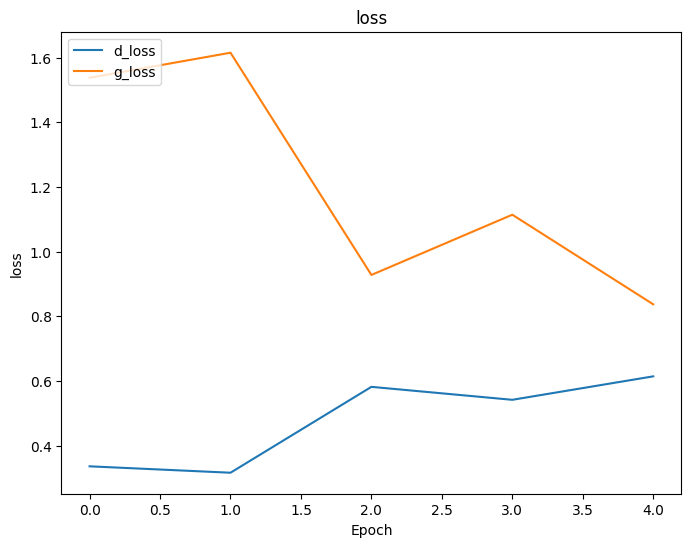

In [13]:
fidle.scrawler.history(history,  plot={'loss':['d_loss','g_loss']}, save_as='01-history')

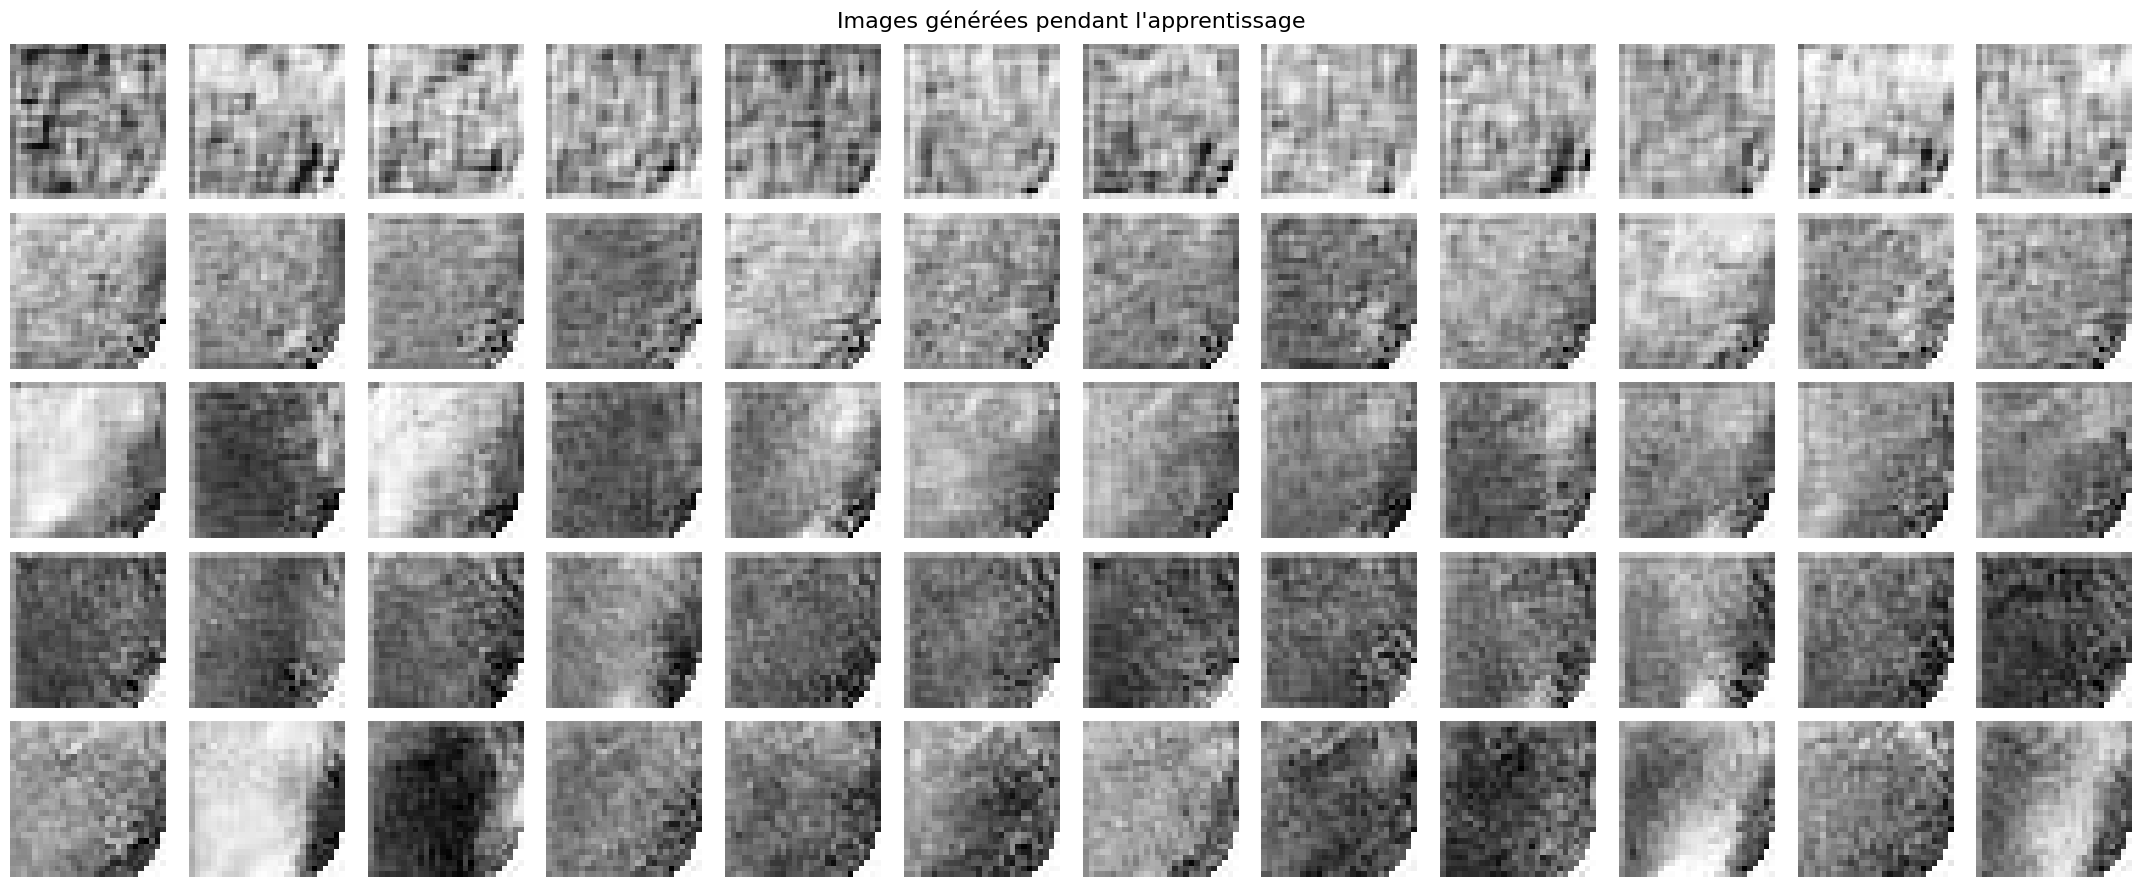

In [14]:
images=[]
for epoch in range(0,epochs,1):
    for i in range(num_img):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image = io.imread(filename)
        images.append(image)

# Visualisation avec la même palette que la cellule 8
fig, axes = plt.subplots(epochs, num_img, figsize=(1.8*num_img, 1.8*epochs))
axes = np.array(axes).reshape(epochs, num_img)
for k, ax in enumerate(axes.flat):
    ax.imshow(np.squeeze(images[k]), cmap='viridis', origin='lower')
    ax.axis('off')
plt.suptitle("Images générées pendant l'apprentissage", fontsize=16)
plt.tight_layout()
plt.show()


## Step 8 - Generation
Reload our saved model :

In [15]:
gan.reload(f'{run_dir}/models/model.h5')


Reloaded.


In [16]:
nb_images = 12*15

z = np.random.normal(size=(nb_images,latent_dim))
images = gan.predict(z, verbose=0)


ValueError: Exception encountered when calling DCGAN.call().

[1mInput 0 with name 'input_layer_1' of layer 'generator' is incompatible with the layer: expected shape=(None, 128), found shape=(32, 64)[0m

Arguments received by DCGAN.call():
  • inputs=tf.Tensor(shape=(32, 64), dtype=float32)

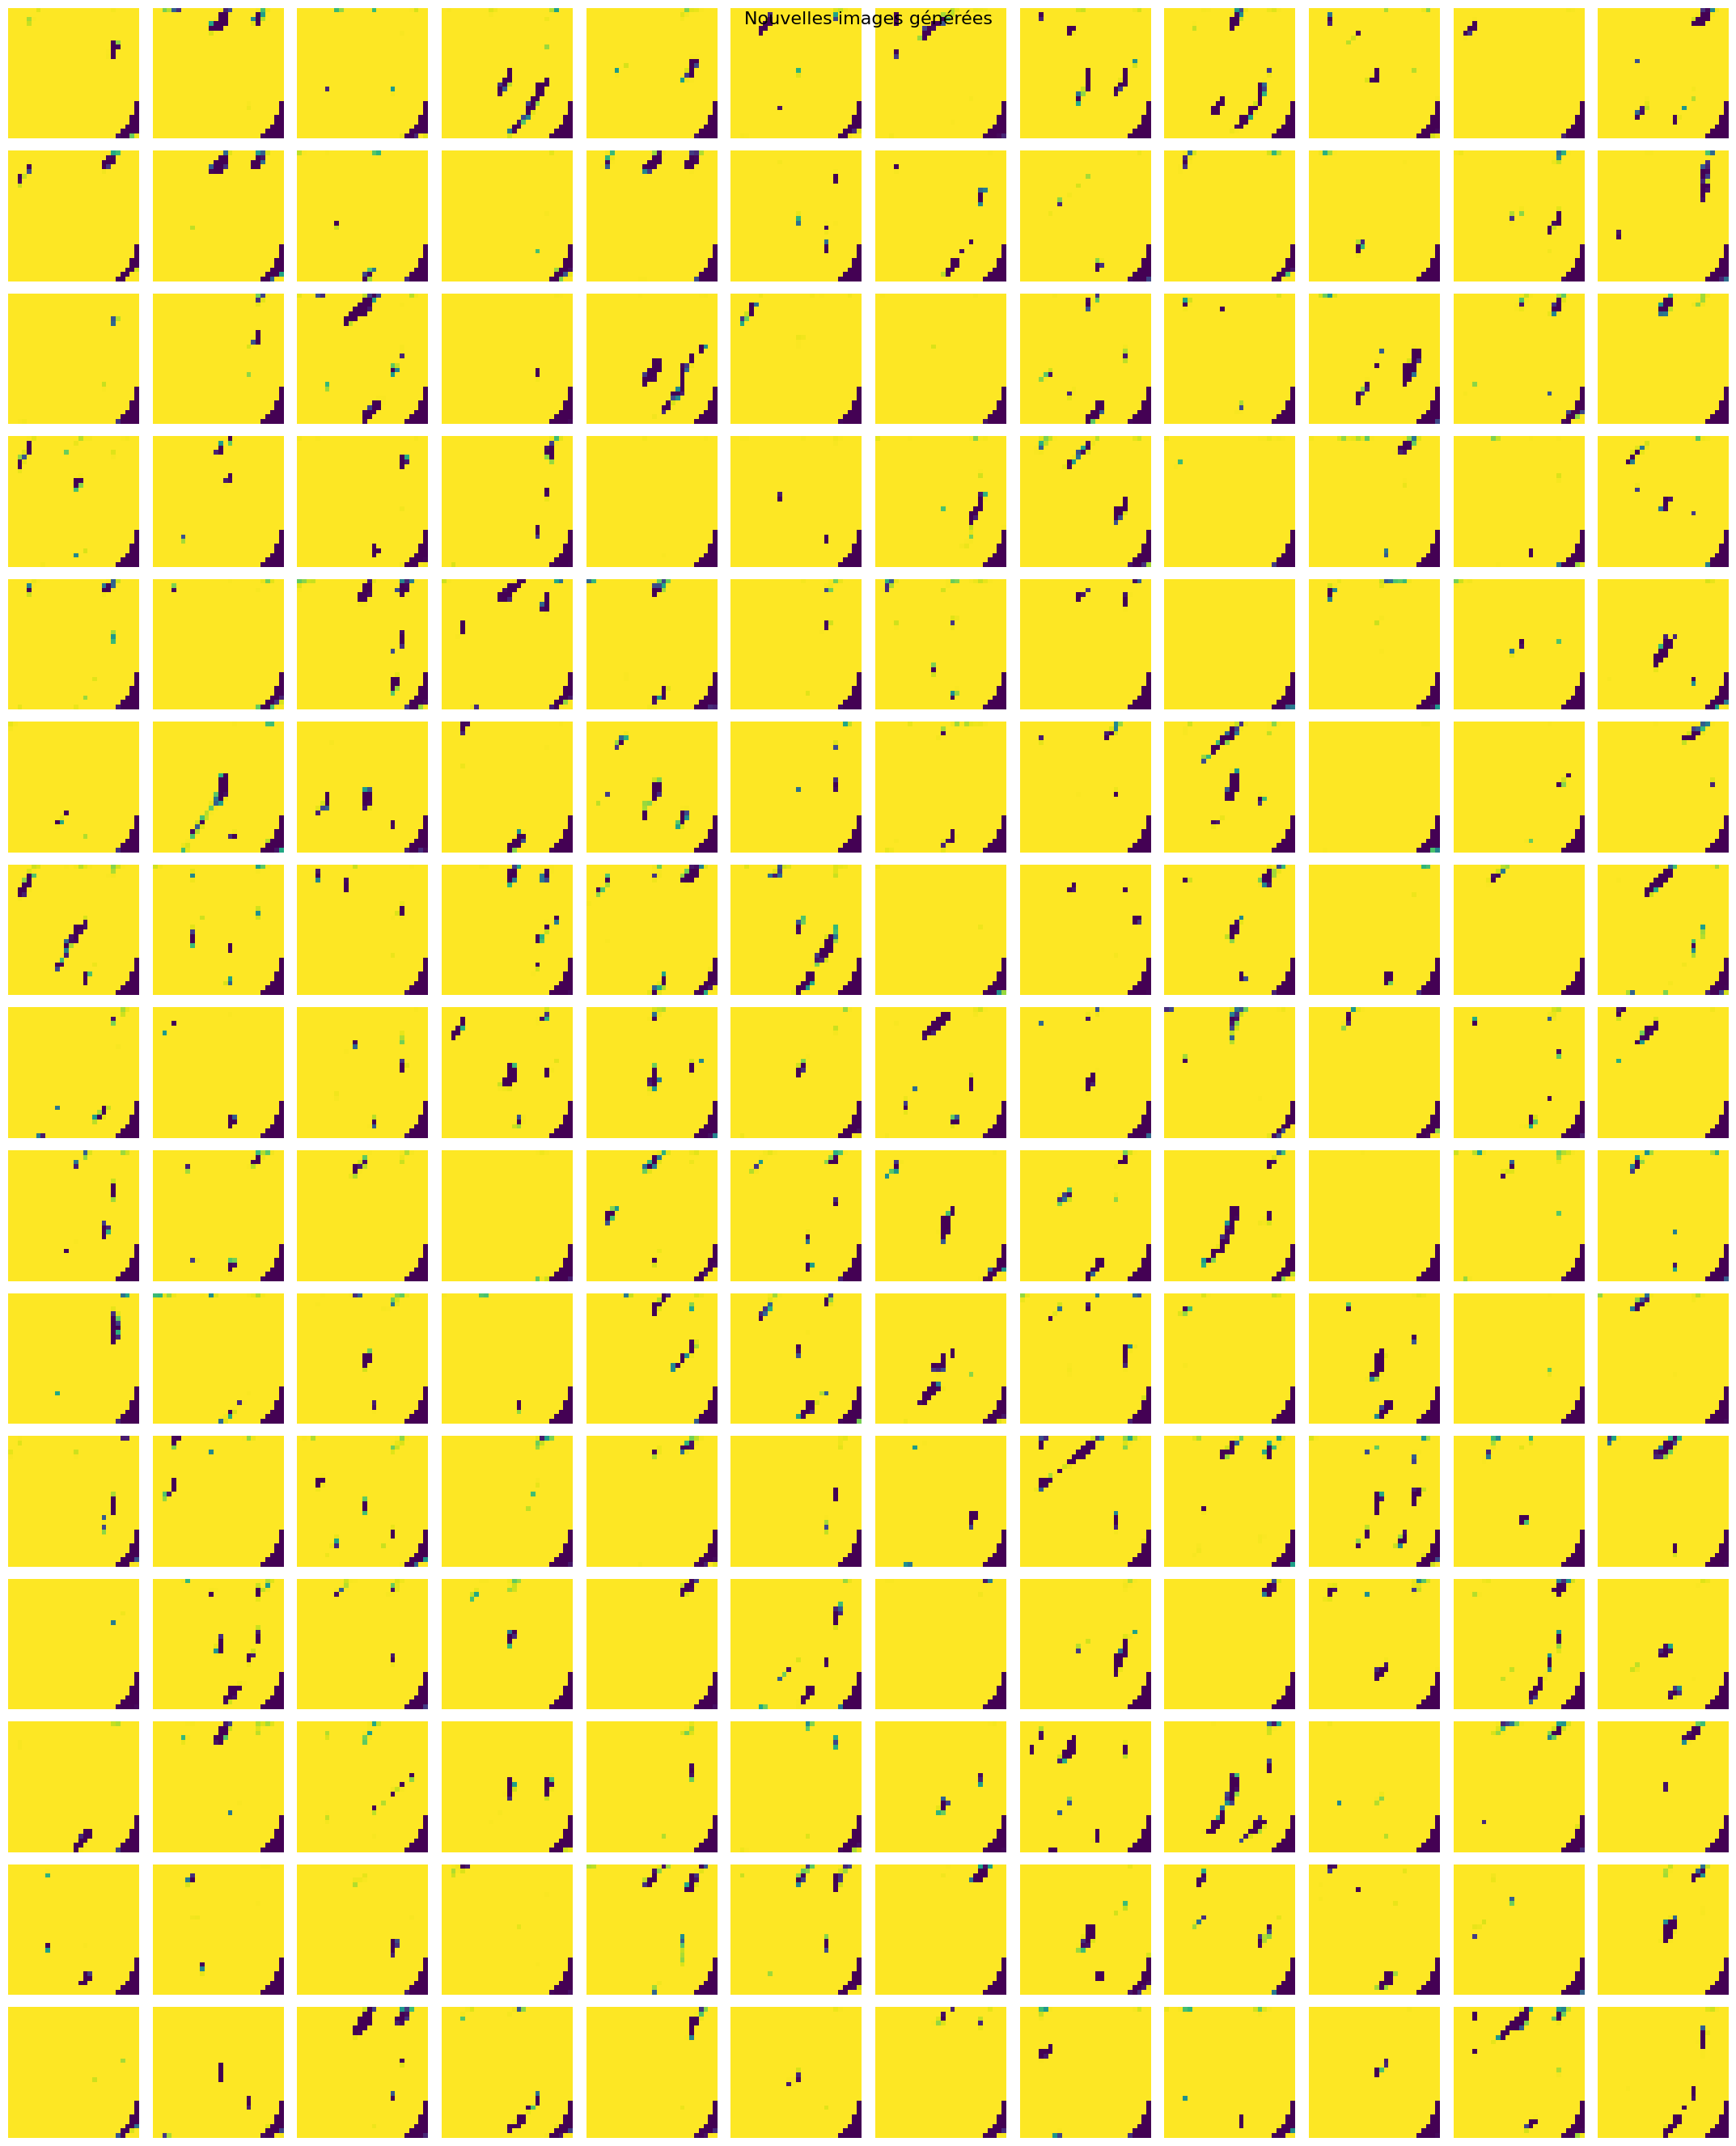

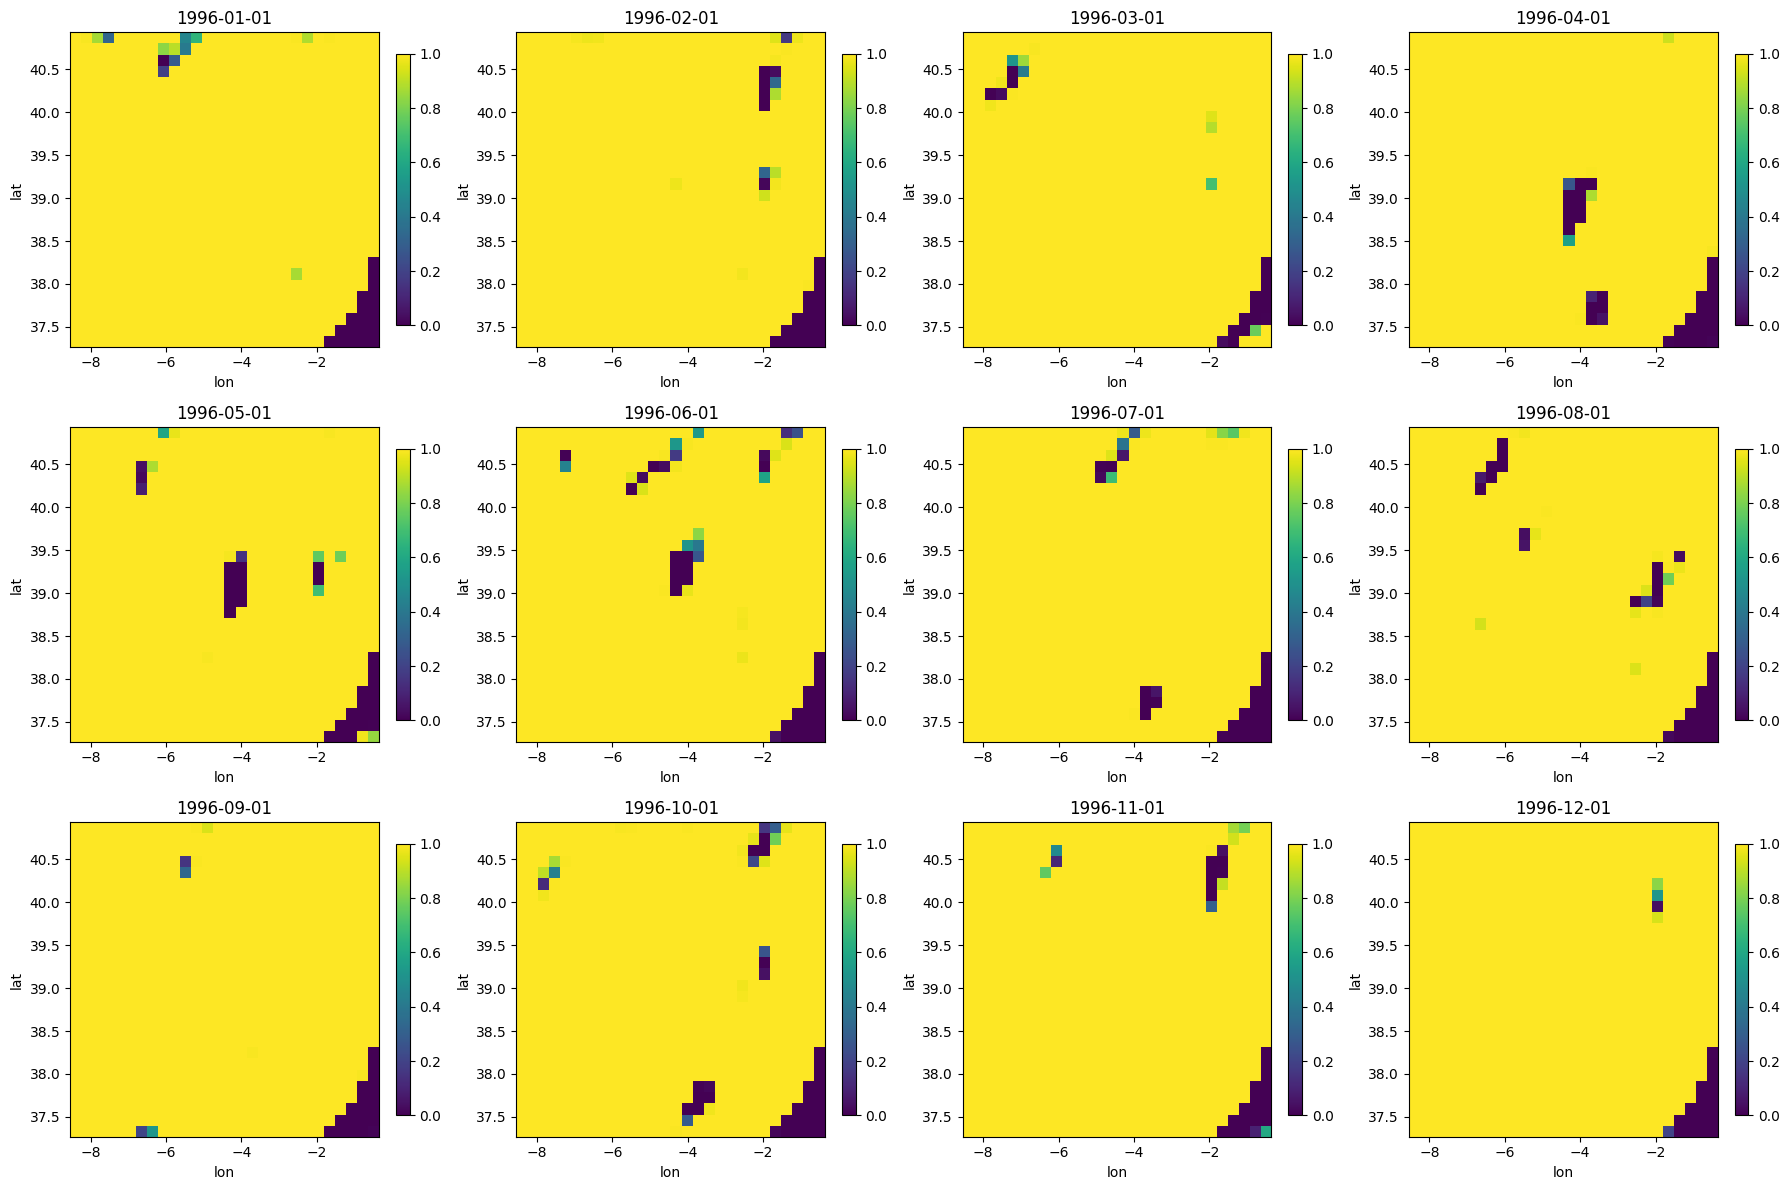

In [ ]:
# Visualisation des images générées aléatoires (même palette)
fig, axes = plt.subplots(15, num_img, figsize=(1.8*num_img, 1.8*15))
axes = axes.flatten()
for ax, img in zip(axes, images):
    ax.imshow(np.squeeze(img), cmap='viridis', origin='lower')
    ax.axis('off')
for ax in axes[len(images):]:
    ax.axis('off')
plt.suptitle('Nouvelles images générées', fontsize=16)
plt.tight_layout()
plt.show()

# Visualisation conditionnée sur les dates de dates_plot
nb_dates = len(dates_plot)
z = np.random.normal(size=(nb_dates, latent_dim))
gen_dates = gan.predict(z, verbose=0)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for ax, img, d in zip(axes, gen_dates, dates_plot):
    im = ax.imshow(np.squeeze(img), cmap='viridis', origin='lower', extent=extent, aspect='auto')
    ax.set_title(str(d)[:10])
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
# ✅ Save figure
plt.savefig(f"{run_dir}/generated_images_gan", dpi=300, bbox_inches="tight")
plt.show()
